# Synthesizing Data for Healthcare Records

Highly sensitive data, such as patient health records, is challenging to analyze and share. Using SDV, you can train generative AI models on your sensitive datasets and then use them to generate synthetic data. The synthetic data mirrors the statistical patterns in your real data and even adhere to the same business logic, but synthetic data will not expose explicit information on specific individuals.

In this tutorial, we will generate synthetic data for healthcare records. We will focus on inspecting the data properties and making sure we configure the synthesizer properly to model the data.

In [1]:
import warnings

warnings.filterwarnings('ignore')

## Understanding the Data

We'll be using a dataset called [SyntheaMass](https://synthea.mitre.org/downloads), which is a multi-table, healthcare dataset containing tables on patients, payers, and more. We'll treat this dataset as our real, sensitive data, use it to train a model in the SDV, and finally use that model to generate synthetic data.

Here's a description of the tables in this dataset:

| Table               | Description                                                                                                               |
|---------------------|---------------------------------------------------------------------------------------------------------------------------|
| patients            | Patient info, including key dates, identifiers, address, and race information                                             |
| encounters          | Patients' encounters with the healthcare system (outpatient care, ambulance care, etc), including dates, payer, and cost. |
| medications         | Patients' medication history, including dates, payer, and cost.                                                           |
| careplans           | Patients' treatment plans, including dates, and type.                                                                     |
| immunizations       | Patients' immunization records, including cost and type.                                                                  |
| observations        | Patients' recorded health metrics, including type and units.                                                              |
| imaging_studies     | Imaging procedure records for patients, including procedure and modality codes.                                           |
| devices             | Issued medical devices to patients, including dates and types.                                                            |
| supplies            | Information on health supplies patients receive or use, including dates and types.                                        |
| allergies           | Patients' allergy records, including dates, severity, and type.                                                           |
| procedures          | Patients' medical procedures, including dates, codes, and reasons.                                                        |
| conditions          | Patients' medical conditions, including dates and description.                                                            |
| payers              | Payer info, including location, revenue, and amount covered.                                                              |
| payer_transitions   | Info on patients and their insurance payer over time, including dates and ownership.                                      |
| organizations       | Info on healthcare organizations, like clinics and hospitals, including location, utilization, and revenue.               |
| providers           | Info on specific clinicians, including location and utilization.                                                          |
| claims              | Info on all insurance claims on behalf of patients, including diagnoses, appointments, statuses, and billing dates.       |
| claims_transactions | Info on all payments made to settle claims, including diagnoses, appointments, and payment details.                       |


This datasets is available as a demo dataset in SDV. To load the datasets we can use the `download_demo` functionality and pass in `synthea` as the name of the dataset. The function will retrieve the dataset and its associated metadata.

Let's start by downloading the data then check that it contains 18 tables.

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(modality='multi_table', dataset_name='synthea')
real_data.keys()

dict_keys(['allergies', 'careplans', 'claims', 'claims_transactions', 'conditions', 'devices', 'encounters', 'imaging_studies', 'immunizations', 'medications', 'observations', 'organizations', 'patients', 'payer_transitions', 'payers', 'procedures', 'providers', 'supplies'])

Some of the columns in the data only contain null values and aren't useful for the SDV, so let's drop them.


In [3]:
null_columns_dict = {}

for name, df in real_data.items():
    null_columns = df.columns[df.isnull().all()]
    null_columns_dict[name] = null_columns.tolist()
    real_data[name].drop(columns=null_columns, inplace=True)

## Updating the Metadata
The metadata is already provided to us, but in cases where we do not have it, we can use SDV's detection functionality to create an initial version of the metadata:
```python3
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(real_data)
```


If we visualize the metadata in a diagram, the complexity of the data stands out to us immediately.

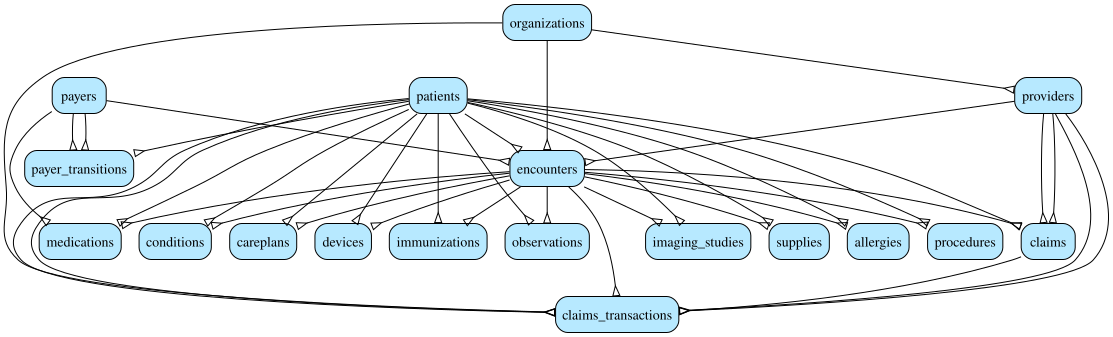

In [5]:
metadata.visualize(show_table_details=None, show_relationship_labels=False)

SDV automatically identified all of the key relationships between the tables in the data so no updates are needed here. Identifying the right sdtype automatically is much more challenging and an imperfect process, so we'll need to inspect the metadata and manually update the sdtypes if needed.


First, let's update the metadata for the `organizations` table. Majority of the fields in this table were assigned the `unknown` sdtype, which means that the SDV will have a hard time generating high quality synthetic values for these columns.

Some columns in `organizations` table with their correct sdtype:

| Column            | Correct SDType | Reason                                                                                   |
|-------------------|----------------|------------------------------------------------------------------------------------------|
| NAME              | categorical    | This will ensure the same organization names are replicated in the synthetic data.       |
| ADDRESS           | address        | SDV will know to generate realistic addresses                                            |
| ZIP               | postcode       | SDV will know to generate realistic postal codes                                         |
| LAT               | latitude       | SDV will know to generate realistic latitude values                                      |
| LON               | longitude      | SDV will know to generate realistic longitude values                                     |
| PHONE             | phone_number   | SDV will know to generate realistic phone numbers                                        |
| REVENUE           | numerical      | SDV will estimate the distribution in the real data and mirror it in the synthetic data. |

We can run the following code snippet to update our metadata to reflect these changes:



In [ ]:
metadata.update_columns_metadata(
    table_name='organizations',
    column_metadata={
        'NAME': { 'sdtype': 'categorical'},
        'ADDRESS': { 'sdtype': 'address' },
        'ZIP': { 'sdtype': 'postcode'},
        'LAT': { 'sdtype': 'latitude'},
        'LON': { 'sdtype': 'longitude'},
        'PHONE': { 'sdtype': 'phone_number'},
        'REVENUE': { 'sdtype': 'numerical'},
    }
)

Next, let's update the `conditions` table.

| Column            | Correct SDType | Reason                                                                                       |
|-------------------|----------------|----------------------------------------------------------------------------------------------|
| START             | datetime       | Let’s specify the datetime format for SDV to use during synthesis.                           |
| STOP              | datetime       | Let’s specify the datetime format for SDV to use during synthesis.                           |
| CODE              | categorical    | The values in this column are fixed and we want SDV to replicate them in the synthetic data. |


We can run the following code snippet to update our metadata to reflect these changes:

In [ ]:
metadata.update_columns_metadata(
    table_name='conditions',
    column_metadata={
        'START': {'sdtype': 'datetime', 'datetime_format': '%Y-%m-%d' },
        'STOP': {'sdtype': 'datetime', 'datetime_format': '%Y-%m-%d'},
        'CODE': {'sdtype': 'categorical'}
    }
)


We also need to update the metadata to remove the columns that contain no information

In [ ]:
for name, columns in null_columns_dict.items():
    for column_name in columns:
        metadata.remove_column(column_name=column_name, table_name=name)

After you've finished modifying the metadata, let's validate the metadata. The following lines of code will validate that our metadata follows the spec that SDV expects and then will validate that the metadata accurately describes the dataset. If both validate successfully, we will see no output.

In [ ]:
metadata.validate()
metadata.validate_data(real_data)

## Adding Constraints and Assigning Transformers

Real world data often has subtle and specific business rules that must be adhered to in synthetic data. To define those rules for the SDV to incorporate during sampling, we need to define these as [Constraints](https://docs.sdv.dev/sdv/single-table-data/modeling/customizations/constraints).

Identifying potential constraints is a bit of an art and we'll walk you through how we identified some of the constraints for this tutorial before showing the code you need to run.

If we look more closely at the `patients` table, we can surmise a link between the **PREFIX** and **GENDER** columns.

In [ ]:
real_data['patients'].head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-02-17,NaN,999-65-3251,NaN,NaN,NaN,Damon455,Langosh790,NaN,...,Middleborough Massachusetts US,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,NaN,999-49-3323,S99941126,NaN,NaN,Thi53,Wunsch504,NaN,...,Danvers Massachusetts US,972 Tillman Branch Suite 48,Bellingham,Massachusetts,Norfolk County,NaN,42.035213,-71.482519,402723.4150,14064.1350
2,339144f8-50e1-633e-a013-f361391c4cff,1998-05-11,NaN,999-10-8743,S99996708,X75063318X,Mr.,Chi716,Greenfelder433,NaN,...,Athens Athens Prefecture GR,1060 Bernhard Crossroad Suite 15,Boston,Massachusetts,Suffolk County,2131.0,42.292557,-71.061160,571935.8725,787.5375
3,d488232e-bf14-4bed-08c0-a82f34b6a197,2003-01-28,NaN,999-56-6057,S99929424,NaN,Ms.,Phillis443,Walter473,NaN,...,Boston Massachusetts US,677 Ritchie Terrace,Hingham,Massachusetts,Plymouth County,2043.0,42.200491,-70.916076,582557.8030,104782.2070
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,1993-12-23,NaN,999-91-4320,S99991143,X44132498X,Mr.,Jerrold404,Herzog843,NaN,...,Boston Massachusetts US,276 Bernier Branch,Revere,Massachusetts,Suffolk County,NaN,42.381875,-70.999286,475826.8550,18067.0950


Both of them indicate information either directly or indirectly about a patient's gender. If we cross-tabulate both of these columns, we can tell that these columns are connected.

In [ ]:
real_data['patients'][['PREFIX', 'GENDER']].value_counts(dropna=False)

PREFIX  GENDER
Mr.     M         431
Mrs.    F         331
Ms.     F         156
NaN     F         129
        M         116
Name: count, dtype: int64

As expected, male patients (M) only have one prefix (Mr.) while female patients have a few (Mrs. or Ms.). From this cross tabulation, we can clearly deduce that these are the only valid combinations of values in these two columns. To guarantee that our synthetic data won't have invalid pairs of values (e.g. a PREFIX of "Mr." with a GENDER of "F"), we need to define this business rule as an instance of the [FixedCombinations constraint](https://docs.sdv.dev/sdv/reference/constraint-logic/predefined-constraint-classes/fixedcombinations). To define it, we just craft a dictionary object that follows the structure in the [documentation](https://docs.sdv.dev/sdv/reference/constraint-logic/predefined-constraint-classes/fixedcombinations) that contains the name of the constraint, relevant table name, and the constraint parameters (in this case the two or more columns involved).

In [ ]:
from sdv.cag import FixedCombinations

patients_constraint_1 = FixedCombinations(
    table_name='patients',
    column_names=['PREFIX', 'GENDER']
)

A similar dependence exists in the `conditions` table, between the **CODE** and **DESCRIPTION** columns.

In [ ]:
real_data['conditions'][['CODE', 'DESCRIPTION']].value_counts(dropna=False)

,,count
CODE,DESCRIPTION,
160903007,Full-time employment (finding),13805
73595000,Stress (finding),5137
160904001,Part-time employment (finding),2426
422650009,Social isolation (finding),1243
444814009,Viral sinusitis (disorder),1233
...,...,...
425048006,Non-small cell carcinoma of lung TNM stage 2 (disorder),1
427089005,Male Infertility,1
431856006,Chronic kidney disease stage 2 (disorder),1


If we inspect all 204 pairs of values in this cross-tabulation, we'll notice that a given code value always maps to the same description value. A code never pairs with two description values. This lines up with our own intuition and understanding of this domain; medical codes (as numbers) are often used to represent another concept.

Let's define this constraint as well.

In [ ]:
conditions_constraint_1 = FixedCombinations(
    table_name='conditions',
    column_names=['CODE', 'DESCRIPTION']
)

FixedCombinations constraints can span multiple columns and the same table can have multiple, non-overlapping constraints that have to be defined. Let's highlight examples from the `imaging_studies` table, starting with the following 4 columns:

In [ ]:
real_data['imaging_studies'][[
    'BODYSITE_CODE',
    'BODYSITE_DESCRIPTION',
    'MODALITY_CODE',
    'MODALITY_DESCRIPTION',
]].value_counts(dropna=False)

,,,,count
BODYSITE_CODE,BODYSITE_DESCRIPTION,MODALITY_CODE,MODALITY_DESCRIPTION,
51185008,Thoracic structure (body structure),CT,Computed Tomography,151094
80891009,Heart structure (body structure),US,Ultrasound,221
51185008,Thoracic structure (body structure),CR,Computed Radiography,104
8205005,Wrist,DX,Digital Radiography,51
40983000,Arm,DX,Digital Radiography,43
344001,Ankle,DX,Digital Radiography,41
51299004,Clavicle,DX,Digital Radiography,36
72696002,Knee,DX,Digital Radiography,18
51185008,Chest,DX,Digital Radiography,13


This table has ~151,000 rows but these columns only contain these 11 specific combinations of values. Another example from the same table is the **SOP_CODE** and **SOP_DESCRIPTION** columns.

In [ ]:
real_data['imaging_studies'][['SOP_CODE', 'SOP_DESCRIPTION']].value_counts(dropna=False)


SOP_CODE                     SOP_DESCRIPTION                               
1.2.840.10008.5.1.4.1.1.2    CT Image Storage                                  151094
1.2.840.10008.5.1.4.1.1.3.1  Ultrasound Multiframe Image Storage                  221
1.2.840.10008.5.1.4.1.1.1.1  Digital X-Ray Image Storage                          214
                             Digital X-Ray Image Storage – for Presentation       104
1.2.840.10008.5.1.4.1.1.6.1  Ultrasound Image Storage                               4
Name: count, dtype: int64

We can define these constraints the same way we did earlier:

In [ ]:
imaging_studies_constraint_1 = FixedCombinations(
    table_name='imaging_studies',
    column_names=[
        'BODYSITE_CODE',
        'BODYSITE_DESCRIPTION',
        'MODALITY_CODE',
        'MODALITY_DESCRIPTION'
    ]
)

imaging_studies_constraint_2 = FixedCombinations(
    table_name='imaging_studies',
    column_names=['SOP_CODE', 'SOP_DESCRIPTION']
)

The remaining constraints in this dataset are all FixedCombinations constraints and follow the same general pattern. There's at least 10 more constraints we need to define.

In [ ]:
## observations table
observations_constraint_1 = FixedCombinations(
    table_name='observations', column_names=['CODE', 'DESCRIPTION']
)
observations_constraint_2 = FixedCombinations(
    table_name='observations', column_names=['UNITS', 'TYPE']
)

## immunizations table
immunizations_constraint_1 = FixedCombinations(
    table_name='immunizations', column_names=['CODE', 'DESCRIPTION']
)

## claims table
claims_constraint_1 = FixedCombinations(
    table_name='claims', column_names=['HEALTHCARECLAIMTYPEID1', 'HEALTHCARECLAIMTYPEID2']
)

## allergies table
allergies_constraint_1 = FixedCombinations(
    table_name='allergies', column_names=['CODE', 'DESCRIPTION']
)
allergies_constraint_2 = FixedCombinations(
    table_name='allergies', column_names=['REACTION1', 'DESCRIPTION1']
)
allergies_constraint_3 = FixedCombinations(
    table_name='allergies', column_names=['REACTION2', 'DESCRIPTION2']
)

## careplans table
careplans_constraint_1 = FixedCombinations(
    table_name='careplans', column_names=['CODE', 'DESCRIPTION']
)
careplans_constraint_2 = FixedCombinations(
    table_name='careplans', column_names=['REASONCODE', 'REASONDESCRIPTION']
)

## imaging studies table
imaging_studies_constraint_3 = FixedCombinations(
    table_name='imaging_studies', column_names=['INSTANCE_UID', 'PROCEDURE_CODE']
)

## device table
devices_constraint_1 = FixedCombinations(
    table_name='devices', column_names=['CODE', 'DESCRIPTION']
)

## encounters table
encounters_constraint_1 = FixedCombinations(
    table_name='encounters', column_names=['CODE', 'DESCRIPTION']
)
encounters_constraint_2 = FixedCombinations(
    table_name='encounters', column_names=['REASONCODE', 'REASONDESCRIPTION']
)

## supplies table
supplies_constraint_1 = FixedCombinations(
    table_name='supplies', column_names=['CODE', 'DESCRIPTION']
)

## claims transactions table
claims_transactions_constraint_1 = FixedCombinations(
    table_name='claims_transactions', column_names=['TYPE', 'METHOD']
)

To incorporate all of these constraints when SDV is generating synthetic data, we need to instantiate a synthesizer object and then attach these constraints to that object.

In [ ]:
from sdv.multi_table import HSASynthesizer

hsa_synthesizer = HSASynthesizer(metadata)

hsa_synthesizer.add_constraints(constraints=[
    patients_constraint_1, conditions_constraint_1,
    observations_constraint_1, observations_constraint_2,
    immunizations_constraint_1, claims_constraint_1,
    allergies_constraint_1, allergies_constraint_2,
    allergies_constraint_3, careplans_constraint_1,
    careplans_constraint_2, imaging_studies_constraint_1,
    imaging_studies_constraint_2, imaging_studies_constraint_3,
    devices_constraint_1, encounters_constraint_1,
    encounters_constraint_2, supplies_constraint_1,
    claims_transactions_constraint_1
])


Our dataset contains two columns that represent phone numbers. To replace them with a random phone number in the synthetic data, let's update the transformers for these columns.

First, we need to start by asking SDV to detect and establish baseline transformers using the [auto_assign_transformers()](https://docs.sdv.dev/sdv/multi-table-data/modeling/customizations/preprocessing#auto_assign_transformers) method.


In [ ]:
hsa_synthesizer.auto_assign_transformers(real_data)

Next, let's use the [update_transformers()](https://docs.sdv.dev/sdv/multi-table-data/modeling/customizations/preprocessing#update_transformers) method to update the assigned transformers for our 2 phone number columns to AnonymizedFaker.

In [ ]:
from rdt.transformers.pii import AnonymizedFaker

hsa_synthesizer.update_transformers(
    table_name='organizations',
    column_name_to_transformer= {'PHONE':
        AnonymizedFaker(provider_name="phone_number",
        function_name="phone_number")
})

hsa_synthesizer.update_transformers(
    table_name='payers',
    column_name_to_transformer={'PHONE':
        AnonymizedFaker(provider_name="phone_number",
        function_name="phone_number")
})


## Generating Synthetic Data and Evaluating Quality

Let's fit the synthesizer and then sample to match the same approximate ratio of rows as our original data.

In [ ]:
hsa_synthesizer.fit(real_data)
synthetic_data = hsa_synthesizer.sample(1.0)

Next, let's generate a [quality report](https://docs.sdv.dev/sdv/multi-table-data/evaluation/data-quality) to understand how well the synthetic data mirrors the patterns in our real data.

In [ ]:
from sdv.evaluation.multi_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata,
    verbose=False
)

/usr/local/lib/python3.12/dist-packages/sdmetrics/_utils_metadata.py:87: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  pd.to_datetime(column_data, format=datetime_format)
/usr/local/lib/python3.12/dist-packages/sdmetrics/_utils_metadata.py:91: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return pd.to_datetime(column_data, format=datetime_format)
/usr/local/lib/python3.12/dist-packages/sdmetrics/_utils_metadata.py:87: FutureWarning: In a future

First, let's unpack how well the SDV mirrored the distribution shapes from the real data, starting with the `patients` table.

In [ ]:
fig = quality_report.get_visualization(
    property_name='Column Shapes',
    table_name='patients')

fig.update_layout(width=1200)
fig.show()

An overall average score of 0.85 is considered very good. Let's specifically compare the distributions of the **HEALTHCARE_EXPENSES** from the patients table.

In [ ]:
from sdv.evaluation.multi_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata,
    table_name='patients',
    column_name='HEALTHCARE_EXPENSES',
    plot_type='distplot'
)

fig.update_layout(width=1200)
fig.show()

We can observe first hand how the high score from the column shapes bar plot for this table reflects the distribution similarity for this specific column. Next, let's look at the `allergies` table.

In [ ]:
fig = quality_report.get_visualization(
    property_name='Column Shapes',
    table_name='allergies')

fig.update_layout(width=1200)
fig.show()

The synthetic data in the `allergies` table also scored very high (0.95). The blue bars represent the [similarity scores](https://docs.sdv.dev/sdmetrics/metrics/metrics-glossary/tvcomplement) for the categorical columns in the real data, which were especially well recreated in the synthetic data.

## Next Steps

We generated healthcare records using SDV and evaluated its quality.
To evaluate how well your synthetic data preserves privacy of sensitive information, we can use the [CategoricalCAP](https://docs.sdv.dev/sdmetrics/metrics/metrics-glossary/categoricalcap#the-cap-algorithm) metric.